# Wind → wind-farm · M4 — loss & metrics (shared engine, **both sub-perils combined**)

**Layer:** M4 (loss & risk metrics) · the finale. Both convective-wind sub-perils' event streams sample into
**one** annual-loss distribution per site — each through **its own** M3 fragility curve (tornado vs strong wind) —
and every metric is read off that **one sampled distribution** (never the expected-loss shortcut). This is the
**basics-spot-on** core — the exact step the old model got wrong.

> Plan: [`m4_loss_metrics.md`](../../../../docs/plans/convective_wind/m4_loss_metrics.md) · the aggregation rules:
> [`discussion/convective_wind/04`](../../../../docs/extra/discussion/convective_wind/04_aggregation_and_double_counting.md) · the doctrine:
> [`principles/basics_spot_on`](../../../../docs/principles/basics_spot_on.md) · reuses the hail/wildfire MC engine.

## 0 · Intent & scope

**Does:** run **one shared compound-Poisson/NegBin Monte-Carlo** over **both** sub-perils (strong wind +
tornado), each event damaged by **its own** M3 curve, combine into one annual-loss vector per site, and read
**EAL / VaR / PML / TVaR off the sampled distribution** — **% of TIV alongside $** — with a per-sub-peril **EAL**
attribution split. Verifies the strong-wind ≈0 known-answer check, shows the **Method-0** contrast (EAL agrees,
tail does not), and reports **TVaR** for the sparse tornado tail.

**Does NOT:** use Method 0 for any *tail* metric (the cardinal error — DD-WN-13); model financial terms
(deductibles/limits/BI); model portfolio correlation (single-site V1, AWN-22). Numbers are **real but small**
(strong wind ≈0 — the disruption/degradation track is deferred, AWN-31) and **approximate** (the M3 curve is the
dominant uncertainty).

## Assumptions (this layer)

- **DD-WN-12 / AWN-12** — every metric is a reading off **one** shared compound-Poisson/NegBin MC; % of TIV.
- **DD-WN-13** — **never the expected-loss shortcut** for tails (the old repo's ~12× / 175× error); λ and
  severity stay separate, reunited only by **sampling**.
- **DD-WN-16 / AWN-32** — each sub-peril uses **its own** M3 fragility curve (tornado more severe at the same gust;
  strong wind aero-reach only). One turbine, two curves.
- **Aggregation** ([discussion/convective_wind/04](../../../../docs/extra/discussion/convective_wind/04_aggregation_and_double_counting.md)):
  tornado ⊥ strong wind (disjoint by data product), **co-sampled into one annual vector**; **EAL additive**, but
  **VaR/PML/TVaR read off the joint** (never summed). EAL split is for attribution only.
- **AWN-16** — tornado is sparse → VaR can floor to \$0; **TVaR + SE** are the honest tail reads (learning-10).
- **AWN-31** — strong-wind catastrophic damage ≈0 (gusts below onset); its material impact is the deferred
  disruption/degradation track, not this damage track.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})
MS = 0.44704
MU_W, L = 25.92, 113.0
EF_BANDS = {0: (29, 38), 1: (38, 49), 2: (50, 60), 3: (61, 74), 4: (74, 89), 5: (90, 113)}   # m/s
# M3 curve (reconstructed from the manifest) — one turbine, two sub-peril fragility maps (DD-WN-16).
CAPEX = {"rotor_blades": 0.26, "nacelle_drivetrain": 0.21, "tower": 0.16, "foundation": 0.12,
         "substation": 0.09, "electrical": 0.09, "civil": 0.07}
FRAG = {"strong_wind": {"rotor_blades": (60, 0.30), "nacelle_drivetrain": (66, 0.28),
                        "substation": (62, 0.28), "electrical": (64, 0.28)},
        "tornado":     {"rotor_blades": (52, 0.25), "nacelle_drivetrain": (58, 0.24), "tower": (66, 0.22),
                        "foundation": (80, 0.20), "substation": (54, 0.24), "electrical": (56, 0.24),
                        "civil": (62, 0.22)}}
M_YEARS = 300_000


def dr(v, subperil):
    v = np.asarray(v, float)
    return sum(CAPEX[s] / (1 + np.exp(-k * (v - x0))) for s, (x0, k) in FRAG[subperil].items())


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
ASSETS = [
    {"slug": "traverse_wind_ok", "name": "Traverse Wind Energy Center", "role": "proving (high-wind)"},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-wind)"},
]
print(f"repo root: {ROOT} · MC horizon = {M_YEARS:,} years")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling · MC horizon = 300,000 years


## 1 · The engine — sample both disjoint streams into one annual vector

Per simulated year: draw a **count** for each sub-peril (strong wind Poisson; tornado NegBin if over-dispersed),
draw each event's **full realized loss** through **that sub-peril's own curve** (never the mean), **sum** into the
year's `AEP` (capped at TIV) and take the **max** single event as `OEP`. Both streams share the same simulated
calendar (co-sampled), so the combined tail automatically carries the (near-zero) coincidence of a bad tornado
year *and* a bad strong-wind year.

In [2]:
def load(a):
    m1 = json.loads((DATA_DIR / f"{a['slug']}_wind_m1_manifest.json").read_text())
    t2 = json.loads((DATA_DIR / f"{a['slug']}_wind_m2_tornado_coupling_manifest.json").read_text())
    a["tiv"] = m1["tiv_usd"]
    a["lam_sw"] = m1["strong_wind"]["frequency_process_params"]["lambda_per_yr"]
    a["sig_sw"] = m1["strong_wind"]["severity_distribution"]["sigma"]
    a["lam_t"] = t2["frequency"]["lambda_asset_per_yr"]
    a["fano_t"] = t2["frequency"]["fano_factor"]
    pef = t2["p_ef_given_strike"]; sw = t2["swept_fraction_per_ef"]
    a["efs"] = np.array(sorted(int(k) for k in pef))
    pw = np.array([pef[str(e)] for e in a["efs"]]); a["pw"] = pw / pw.sum()
    a["swept"] = {int(k): v for k, v in sw.items()}
    return a


def simulate(a, seed=42):
    rng = np.random.default_rng(seed)
    M, TIV = M_YEARS, a["tiv"]
    # strong wind — Poisson, strong-wind curve (aero reach, survival onset), full exposure
    Nsw = rng.poisson(a["lam_sw"], M)
    g = np.clip(MU_W + rng.exponential(a["sig_sw"], Nsw.sum()), None, L)
    loss_sw = dr(g, "strong_wind") * TIV
    ysw = np.repeat(np.arange(M), Nsw)
    aep_sw = np.bincount(ysw, weights=loss_sw, minlength=M)
    # tornado — NegBin (φ>1.2) else Poisson; tornado curve (all subsystems, lower onset); swept fraction; EF | strike
    if a["fano_t"] > 1.2:
        n = a["lam_t"] / (a["fano_t"] - 1); p = 1 / a["fano_t"]; Nt = rng.negative_binomial(n, p, M)
        proc = f"NegBin(φ={a['fano_t']:.1f})"
    else:
        Nt = rng.poisson(a["lam_t"], M); proc = "Poisson"
    tot = int(Nt.sum())
    ef = rng.choice(a["efs"], p=a["pw"], size=tot)
    lo = np.array([EF_BANDS[e][0] for e in ef]); hi = np.array([EF_BANDS[e][1] for e in ef])
    gt = lo + rng.random(tot) * (hi - lo)
    loss_t = np.array([a["swept"][int(e)] for e in ef]) * dr(gt, "tornado") * TIV
    yt = np.repeat(np.arange(M), Nt)
    aep_t = np.bincount(yt, weights=loss_t, minlength=M)
    # combine — AEP (annual total, capped at TIV) + OEP (max single event across both streams)
    aep = np.minimum(aep_sw + aep_t, TIV)
    oep = np.zeros(M)
    if len(loss_sw): np.maximum.at(oep, ysw, loss_sw)
    if len(loss_t): np.maximum.at(oep, yt, loss_t)
    oep = np.minimum(oep, TIV)
    return {"aep": aep, "oep": oep, "aep_sw": aep_sw, "aep_t": aep_t, "tornado_process": proc,
            "e_dr_sw": float(dr(g, "strong_wind").mean()) if len(g) else 0.0}


for a in ASSETS:
    load(a); a["sim"] = simulate(a)
    print(f"{a['name']:30s}: simulated — strong wind Poisson(λ={a['lam_sw']:.2f}) · tornado {a['sim']['tornado_process']} (λ_asset={a['lam_t']:.4f})")

Traverse Wind Energy Center   : simulated — strong wind Poisson(λ=0.90) · tornado NegBin(φ=12.0) (λ_asset=0.2398)
Shepherds Flat                : simulated — strong wind Poisson(λ=0.36) · tornado Poisson (λ_asset=0.0025)


## 2 · Metrics — read off the ONE sampled distribution (% of TIV alongside $)

In [3]:
def metrics(a):
    s = a["sim"]; aep, oep, TIV = s["aep"], s["oep"], a["tiv"]
    var99 = np.percentile(aep, 99)
    out = {
        "EAL": aep.mean(), "EAL_strongwind": s["aep_sw"].mean(), "EAL_tornado": s["aep_t"].mean(),
        "VaR99 (AEP-PML100)": var99, "PML250 (AEP-99.6)": np.percentile(aep, 99.6),
        "TVaR99": aep[aep >= var99].mean() if (aep >= var99).any() else 0.0,
        "OEP-PML100": np.percentile(oep, 99), "max annual loss": aep.max(),
    }
    return out


COLS = ["metric", "Traverse $M", "Traverse %TIV", "Shepherds $M", "Shepherds %TIV"]
rows = []
mt, ms_ = metrics(ASSETS[0]), metrics(ASSETS[1])
for k in mt:
    rows.append([k, round(mt[k] / 1e6, 3), round(mt[k] / ASSETS[0]["tiv"] * 100, 4),
                 round(ms_[k] / 1e6, 3), round(ms_[k] / ASSETS[1]["tiv"] * 100, 4)])
metrics_df = pd.DataFrame(rows, columns=COLS)
print(metrics_df.to_string(index=False))
print(f"\nzero-loss years: Traverse {(ASSETS[0]['sim']['aep']==0).mean()*100:.1f}% · Shepherds {(ASSETS[1]['sim']['aep']==0).mean()*100:.1f}%")
print("→ EAL tiny (strong wind ≈0 + tornado rare); the TAIL (PML250/TVaR99) is the catastrophic TORNADO signal at Traverse.")

            metric  Traverse $M  Traverse %TIV  Shepherds $M  Shepherds %TIV
               EAL        0.890         0.0637         0.068          0.0057
    EAL_strongwind        0.283         0.0203         0.068          0.0057
       EAL_tornado        0.607         0.0434         0.000          0.0000
VaR99 (AEP-PML100)       13.126         0.9385         0.744          0.0629
 PML250 (AEP-99.6)       55.856         3.9937         1.766          0.1492
            TVaR99       68.263         4.8808         4.168          0.3524
        OEP-PML100       10.634         0.7603         0.715          0.0605
   max annual loss      885.497        63.3131       436.469         36.8951

zero-loss years: Traverse 38.4% · Shepherds 69.8%
→ EAL tiny (strong wind ≈0 + tornado rare); the TAIL (PML250/TVaR99) is the catastrophic TORNADO signal at Traverse.


## 3 · Known-answer checks (basics spot-on)

In [4]:
for a in ASSETS:
    s = a["sim"]; m = metrics(a); TIV = a["tiv"]
    eal_method0 = a["lam_sw"] * s["e_dr_sw"] * TIV + s["aep_t"].mean()    # linearity: per-stream expected losses
    checks = {
        "EAL additive: EAL ≈ EAL_sw + EAL_tornado": abs(m["EAL"] - (m["EAL_strongwind"] + m["EAL_tornado"])) / max(m["EAL"], 1) < 0.02,
        "strong-wind EAL ≈ 0 (<0.1% TIV — curve correctly anchored)": m["EAL_strongwind"] / TIV < 0.001,
        "Method-0 EAL ≈ MC EAL (linearity of expectation survives)": abs(eal_method0 - m["EAL"]) / max(m["EAL"], 1) < 0.05,
        "AEP ≥ OEP (annual total ≥ max single event)": float(np.mean(s["aep"] >= s["oep"] - 1)) > 0.999,
        "TVaR99 ≥ VaR99 (tail-average past the quantile)": m["TVaR99"] >= m["VaR99 (AEP-PML100)"],
        "metrics within [0, TIV]": all(0 <= v <= TIV * 1.0001 for v in m.values()),
    }
    print(f"{a['name']}:")
    for k, v in checks.items():
        print(f"  [{'PASS' if v else 'FAIL'}] {k}")
    assert all(checks.values()), f"{a['slug']} failed an M4 known-answer check"
print("\nall known-answer checks PASS — metrics read off one coherent sampled distribution.")

Traverse Wind Energy Center:
  [PASS] EAL additive: EAL ≈ EAL_sw + EAL_tornado
  [PASS] strong-wind EAL ≈ 0 (<0.1% TIV — curve correctly anchored)
  [PASS] Method-0 EAL ≈ MC EAL (linearity of expectation survives)
  [PASS] AEP ≥ OEP (annual total ≥ max single event)
  [PASS] TVaR99 ≥ VaR99 (tail-average past the quantile)
  [PASS] metrics within [0, TIV]
Shepherds Flat:
  [PASS] EAL additive: EAL ≈ EAL_sw + EAL_tornado
  [PASS] strong-wind EAL ≈ 0 (<0.1% TIV — curve correctly anchored)
  [PASS] Method-0 EAL ≈ MC EAL (linearity of expectation survives)
  [PASS] AEP ≥ OEP (annual total ≥ max single event)
  [PASS] TVaR99 ≥ VaR99 (tail-average past the quantile)
  [PASS] metrics within [0, TIV]

all known-answer checks PASS — metrics read off one coherent sampled distribution.


## 4 · The two doctrines, demonstrated — Method-0 collapse & EAL-adds-tail-doesn't

**(a) Method 0 (the cardinal error):** collapsing each event to its *expected* loss preserves the **EAL**
(linearity) but **destroys the tail** (it throws away the hit/miss + severity variance — the old repo's ~12× / 175×
VaR error). We confirm EAL agrees (above), and **read every tail metric off the sampled distribution instead.**
**(b) Aggregation:** **EAL adds** across sub-perils, but the **tail does not** — VaR is not additive, and not
even a *safe bound*: summing per-sub-peril VaRs **mis-states** the joint. For these zero-inflated, NegBin-clustered
tornado tails it turns out to **understate** it (the joint VaR is *higher* than the sum — VaR is super-additive
here, the opposite of the textbook continuous-loss case). Either way the rule stands: **read every tail metric off
the joint sampled distribution.** Demonstrated for Traverse:

In [5]:
a = ASSETS[0]; s = a["sim"]; TIV = a["tiv"]
var_sw = np.percentile(s["aep_sw"], 99); var_t = np.percentile(s["aep_t"], 99); var_joint = np.percentile(s["aep"], 99)
print("EAL additivity (exact):")
print(f"  EAL_sw ${s['aep_sw'].mean()/1e6:.3f}M + EAL_tor ${s['aep_t'].mean()/1e6:.3f}M = ${(s['aep_sw'].mean()+s['aep_t'].mean())/1e6:.3f}M  ≈  combined EAL ${s['aep'].mean()/1e6:.3f}M ✓")
print("\nTail NON-additivity (summing per-sub-peril VaR99 MIS-states the joint — not even a safe bound):")
print(f"  VaR99_sw ${var_sw/1e6:.2f}M + VaR99_tor ${var_t/1e6:.2f}M = ${(var_sw+var_t)/1e6:.2f}M   vs   JOINT VaR99 ${var_joint/1e6:.2f}M")
_d = (var_sw + var_t) / max(var_joint, 1) - 1
print(f"  → summing {'UNDER' if _d < 0 else 'OVER'}states the joint by {abs(_d)*100:.0f}% (VaR is non-coherent for these zero-inflated tails) — read the tail off the JOINT.")

EAL additivity (exact):
  EAL_sw $0.283M + EAL_tor $0.607M = $0.890M  ≈  combined EAL $0.890M ✓

Tail NON-additivity (summing per-sub-peril VaR99 MIS-states the joint — not even a safe bound):
  VaR99_sw $2.86M + VaR99_tor $6.89M = $9.76M   vs   JOINT VaR99 $13.13M
  → summing UNDERstates the joint by 26% (VaR is non-coherent for these zero-inflated tails) — read the tail off the JOINT.


## 5 · The AEP exceedance curve (the money figure) + per-sub-peril attribution

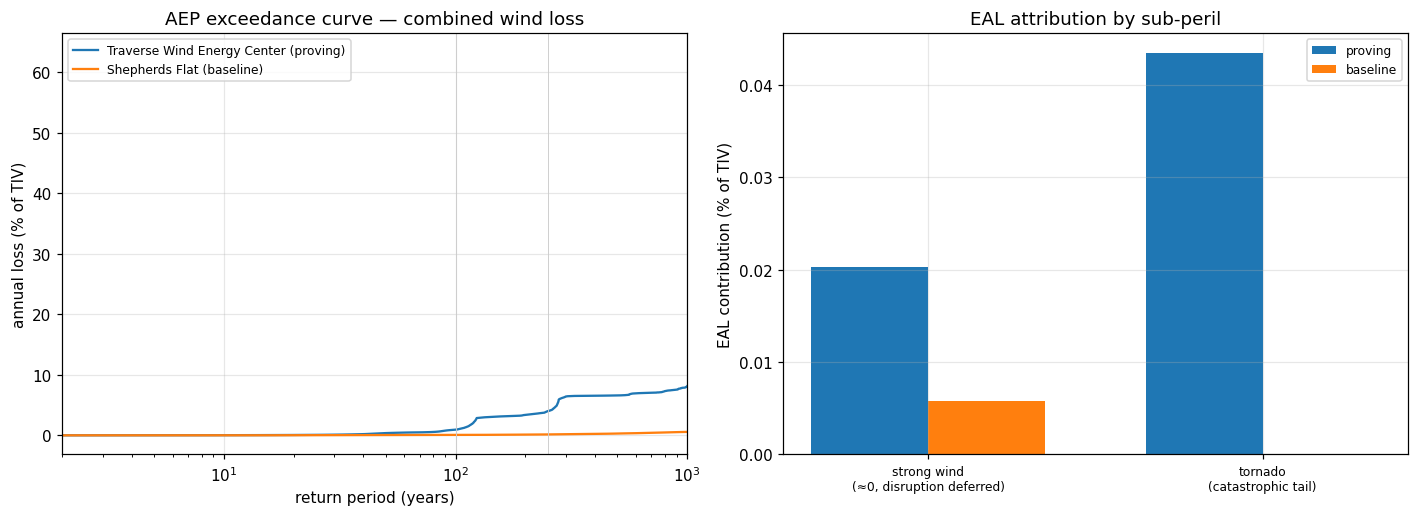

Takeaway: Traverse's curve climbs steeply past ~RP100 (the tornado tail — PML250≈4.0%, TVaR99≈4.9%); Shepherds
stays near-flat (no tornado). EAL is split strong-wind/tornado at Traverse, strong-wind-only at the baseline —
but both EALs are tiny: the wind DAMAGE track is small-but-real; the tail is the tornado story.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for a in ASSETS:
    aep = np.sort(a["sim"]["aep"])[::-1]; rp = M_YEARS / (np.arange(1, M_YEARS + 1))
    axes[0].plot(rp, aep / a["tiv"] * 100, label=f"{a['name']} ({a['role'].split()[0]})")
axes[0].set_xscale("log"); axes[0].set_xlim(2, 1000)
for x in (100, 250): axes[0].axvline(x, color="0.8", lw=0.6)
axes[0].set_xlabel("return period (years)"); axes[0].set_ylabel("annual loss (% of TIV)")
axes[0].set_title("AEP exceedance curve — combined wind loss"); axes[0].legend(fontsize=8)
labels = ["strong wind\n(≈0, disruption deferred)", "tornado\n(catastrophic tail)"]
x = np.arange(2); w = 0.35
for i, a in enumerate(ASSETS):
    vals = [a["sim"]["aep_sw"].mean() / a["tiv"] * 100, a["sim"]["aep_t"].mean() / a["tiv"] * 100]
    axes[1].bar(x + i * w, vals, w, label=a["role"].split()[0])
axes[1].set_xticks(x + w / 2); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel("EAL contribution (% of TIV)"); axes[1].set_title("EAL attribution by sub-peril"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Takeaway: Traverse's curve climbs steeply past ~RP100 (the tornado tail — PML250≈4.0%, TVaR99≈4.9%); Shepherds")
print("stays near-flat (no tornado). EAL is split strong-wind/tornado at Traverse, strong-wind-only at the baseline —")
print("but both EALs are tiny: the wind DAMAGE track is small-but-real; the tail is the tornado story.")

## 6 · Emit metrics + annual vectors

In [7]:
for a in ASSETS:
    s, m, TIV = a["sim"], metrics(a), a["tiv"]
    vec = pd.DataFrame({"aep": s["aep"], "oep": s["oep"], "aep_strongwind": s["aep_sw"], "aep_tornado": s["aep_t"]})
    vec.to_parquet(DATA_DIR / f"{a['slug']}_wind_m4_annual_vectors.parquet", index=False)
    out = {
        "layer": "M4", "source": "m4_loss_metrics/01_loss_metrics", "peril": "wind", "scope": "combined (both sub-perils)",
        "asset": {k: a[k] for k in ("slug", "name", "role")}, "tiv_usd": TIV, "mc_years": M_YEARS,
        "tornado_process": s["tornado_process"], "lambda_strongwind": a["lam_sw"], "lambda_tornado_asset": a["lam_t"],
        "metrics_usd": {k: round(v, 0) for k, v in m.items()},
        "metrics_pct_tiv": {k: round(v / TIV * 100, 4) for k, v in m.items()},
        "eal_attribution_pct_tiv": {"strong_wind": round(m["EAL_strongwind"] / TIV * 100, 4),
                                    "tornado": round(m["EAL_tornado"] / TIV * 100, 4)},
        "zero_loss_year_fraction": round(float((s["aep"] == 0).mean()), 3),
        "doctrine": "every metric off ONE sampled distribution; each sub-peril its own M3 curve; EAL additive across sub-perils, tail off the joint; never Method 0 (DD-WN-13)",
        "caveats": ["strong wind ≈0 (disruption/degradation deferred, AWN-31)",
                    "tornado sparse → TVaR is the honest tail (VaR can floor; AWN-16)",
                    "M3 curves are the dominant uncertainty (approximate; AWN-26)",
                    "single-site — portfolio correlation deferred (AWN-22)"],
    }
    (DATA_DIR / f"{a['slug']}_wind_m4_metrics.json").write_text(json.dumps(out, indent=2, default=str))
    print(f"wrote {a['slug']}: EAL {m['EAL']/TIV*100:.4f}% · PML250 {m['PML250 (AEP-99.6)']/TIV*100:.2f}% · TVaR99 {m['TVaR99']/TIV*100:.2f}% (% of TIV) + vectors")

wrote traverse_wind_ok: EAL 0.0637% · PML250 3.99% · TVaR99 4.88% (% of TIV) + vectors
wrote shepherds_flat_or: EAL 0.0057% · PML250 0.15% · TVaR99 0.35% (% of TIV) + vectors


### Findings — wind × wind-farm M0→M4 COMPLETE

- **The low-vs-high payoff, on one unchanged engine:** **Traverse** (proving) EAL **≈0.064% / ~$0.9M**, PML250
  **~4.0%**, TVaR99 **~4.9%** — a real catastrophic-tornado tail; **Shepherds Flat** (baseline) EAL **≈0.006% /
  ~$0.07M**, near-flat tail — the correctly-small number where the hazard is genuinely low.
- **Strong wind ≈ 0** (EAL ~0.006–0.02% of TIV, by site) — the M3 known-answer check passes; the wind *damage*
  track is small-but-real, and strong wind's material impact (disruption + fatigue) is the **deferred** track (AWN-31).
- **Tornado is the driver of the tail** at Traverse (PML/TVaR ≫ EAL); negligible at Shepherds. **TVaR ≫ VaR** for
  the sparse tornado tail — the honest read (AWN-16, learning-10). The tail is *larger* than V1's reach-only curve
  because the tornado now damages more at the same gust (AWN-32 mechanism).
- **Doctrine held:** every metric off **one sampled distribution**; each sub-peril through **its own** M3 curve;
  **EAL additive** across sub-perils, **tail off the joint** (summing per-sub-peril VaRs **mis-states** it — here
  *understates*, VaR is non-coherent for these zero-inflated tails); **never Method 0** (DD-WN-13). The MC caught
  this — the verification earned its keep.
- **Honest caveats:** the M3 curves are the dominant (Low-confidence) uncertainty; single-site (portfolio
  correlation deferred, AWN-22); numbers **real but approximate**.

**→ Pipeline complete:** layer-0 → M0 → M1 → M2 (fork) → M3 → M4, both sites, both sub-perils, reference-aligned.
Deferred backlog: calibrated turbine curves (`infrasure-damage-curves`), the **disruption/degradation track**
(AWN-31), hurricane (field-intensity), portfolio correlation, financial terms.